# Visualisation of grid generation results

This notebook explains the elements of a pylovo grid on a map. For one grid the elements (postcode area, buildings, building clusters, transformer, streets, cables) are added step by step. The basemap tiles are downloaded from OpenStreetMap (internet access needed).

**Prerequisites**

- pylovo installed with the `notebooks` extra (`uv sync --extra notebooks`) and this notebook running on the kernel of the project environment (`.venv`), see `notebook_tutorials/README.md`.
- A `.env` in the repository root that points to your pylovo database, a completed `pylovo-setup` and generated grids for the postcode area (PLZ) below, e.g. `pylovo-generate --plz 85653`.
- Grids are read for the `VERSION_ID` of `config/config_generation.yaml`.

The stored outputs were generated for the demo postcode area 85653 (Aying), whose buildings, streets and transformers are derived from OpenStreetMap. Map data © OpenStreetMap contributors (ODbL).

In [1]:
# Parameters
plz = 85653  # postcode area with generated grids
kcid = None  # k-means cluster id of the grid; None: first grid of the PLZ
bcid = None  # building cluster id of the grid; None: first grid of the PLZ

## Setup

In [2]:
import warnings

import contextily as cx
import geopandas as gpd
from matplotlib import pyplot as plt

from pylovo.config_loader import VERSION_ID
from pylovo.database.database_client import DatabaseClient
from pylovo.plotting.gis_preparation.io_geodata import get_bus_line_geo_for_network

warnings.filterwarnings("ignore")
# tile.openstreetmap.org serves an "Access blocked" image to contextily's default user agent.
# Its tile usage policy asks for a user agent that identifies the application.
cx.tile.USER_AGENT = "pylovo-notebook-tutorials (+https://github.com/tum-ens/pylovo)"


In [3]:
dbc = DatabaseClient()  # read-only access (GridGenerator is only needed to generate grids)
cluster_list = dbc.get_list_from_plz(plz)
if not cluster_list:
    raise ValueError(f"No grids of version {VERSION_ID} for PLZ {plz}. Run: pylovo-generate --plz {plz}")
if kcid is None or bcid is None:
    kcid, bcid = cluster_list[0]
print(f"PLZ {plz}, version {VERSION_ID}: {len(cluster_list)} grids; selected kcid={kcid}, bcid={bcid}")

PLZ 85653, version 1: 4 grids; selected kcid=1, bcid=1


## Postcode area
As a preliminary step we look at the selected PLZ area.

*Map data © OpenStreetMap contributors (ODbL).*

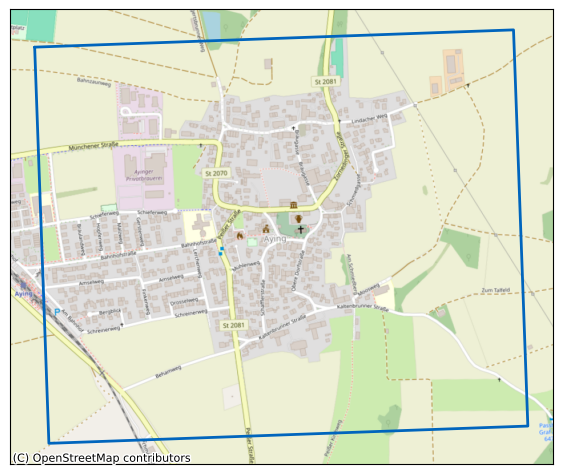

In [4]:
postcode_gdf = dbc.get_geo_df(table="postcode_result", postcode_result_plz=plz)
fig, ax = plt.subplots(figsize=(7, 7))
postcode_gdf.boundary.plot(ax=ax, linewidth=2)
cx.add_basemap(ax, crs=postcode_gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
ax.set_xticks([])
ax.set_yticks([]);

## Buildings
The buildings of all grids in the PLZ area:

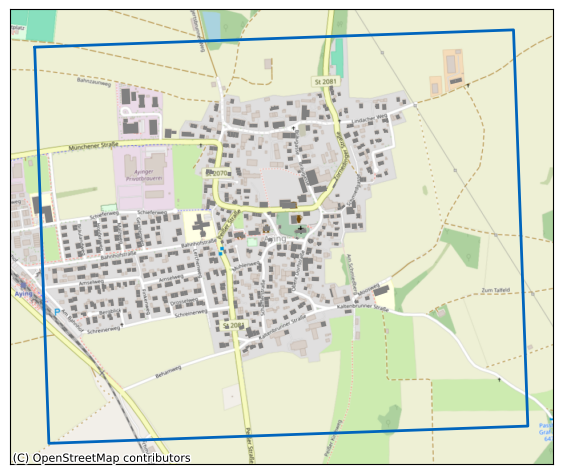

In [5]:
buildings_gdf = dbc.get_geo_df_join(
    ["gr.kcid", "gr.bcid", "br.*"],
    "buildings_result br", "grid_result gr",
    ("br.grid_result_id", "gr.grid_result_id"),
    plz=plz,
)
buildings_gdf.plot(ax=ax, color="grey")
fig

## Building clusters
A PLZ area contains multiple LV grids. Nearby buildings are clustered to form one grid. The convex hulls of the clusters overlap and are hard to read:

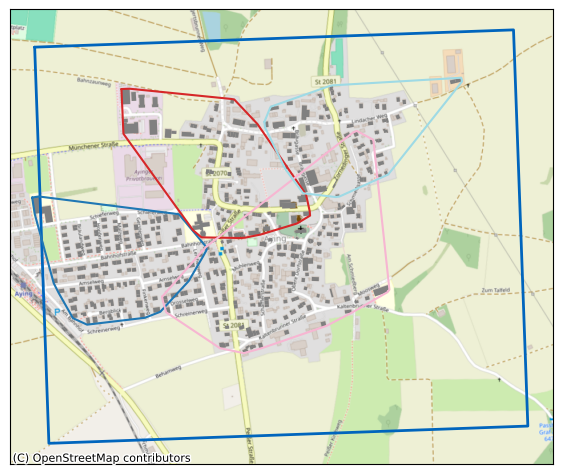

In [6]:
buildings_gdf.dissolve(by="bcid").convex_hull.boundary.plot(ax=ax, cmap="tab20")
fig

Colouring the buildings by cluster is clearer:

*Map data © OpenStreetMap contributors (ODbL).*

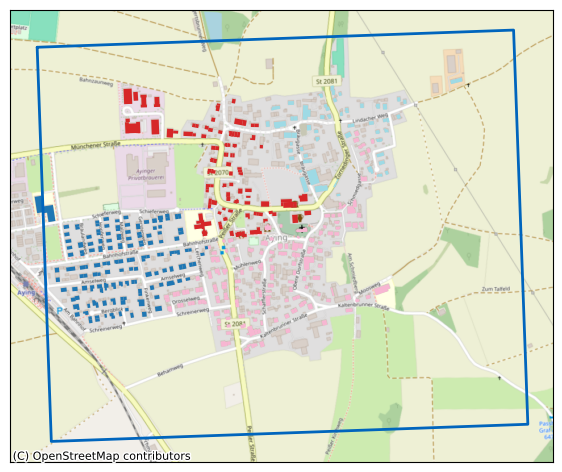

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
postcode_gdf.boundary.plot(ax=ax, linewidth=2)
buildings_gdf.plot(ax=ax, column="bcid", cmap="tab20")
cx.add_basemap(ax, crs=postcode_gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
ax.set_xticks([])
ax.set_yticks([]);

Label the clusters with their `bcid`:

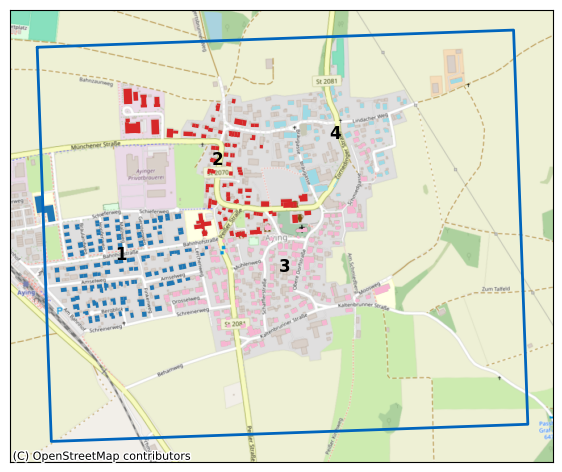

In [8]:
cluster_centroids = buildings_gdf.dissolve(by="bcid").centroid
for cluster_bcid, point in cluster_centroids.items():
    ax.text(point.x, point.y, cluster_bcid, fontsize=12, fontweight="bold")
fig

## One LV grid
We now focus on the selected grid (`kcid`, `bcid` from the parameter cell). All grids of the PLZ:

In [9]:
cluster_list

[(1, 1), (1, 2), (1, 3), (1, 4)]

### Buildings
The consumers are situated in the buildings. The number of buildings supplied by the grid:

In [10]:
grid_buildings_gdf = buildings_gdf[(buildings_gdf.kcid == kcid) & (buildings_gdf.bcid == bcid)]
len(grid_buildings_gdf)

144

The buildings are coloured by their estimated peak load. The peak load depends on the building type (residential, commercial, public), the floor area and the number of households.

*Map data © OpenStreetMap contributors (ODbL).*

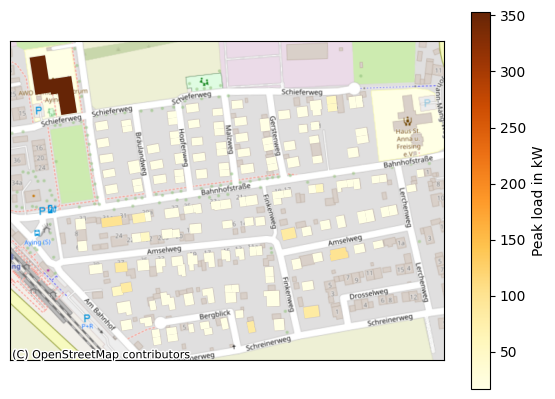

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xticks([])
ax.set_yticks([])
grid_buildings_gdf.plot(ax=ax, column="peak_load_in_kw", cmap="YlOrBr",
                        legend=True, legend_kwds={"label": "Peak load in kW", "shrink": 0.7})
cx.add_basemap(ax, crs=grid_buildings_gdf.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

### Transformer
Each grid needs a transformer that connects the LV grid to the MV distribution grid. The transformer is either an existing one (OSM or DSO data) or placed by pylovo.

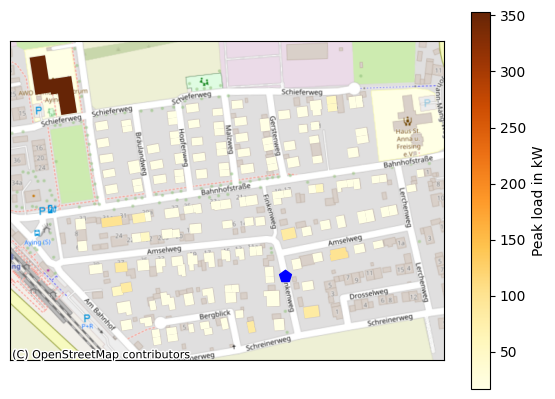

In [12]:
trafo_gdf = dbc.get_geo_df_join(
    ["tp.geom", "tp.osm", "tp.comment"],
    "transformer_positions tp", "grid_result gr",
    ("tp.grid_result_id", "gr.grid_result_id"),
    plz=plz, kcid=kcid, bcid=bcid,
)
trafo_point = trafo_gdf.geom.iloc[0]
ax.scatter(trafo_point.x, trafo_point.y, marker=(5, 0), s=80, color="blue", label="Transformer")
fig

## Streets
Cables are laid along the streets; the buildings are connected from the street.

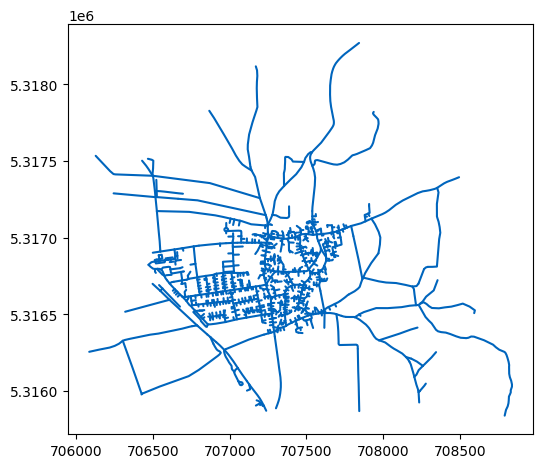

In [13]:
ways_gdf = dbc.get_geo_df(table="ways_result", plz=plz)
ways_gdf.plot(figsize=(6, 6));

We keep the streets around the selected grid:

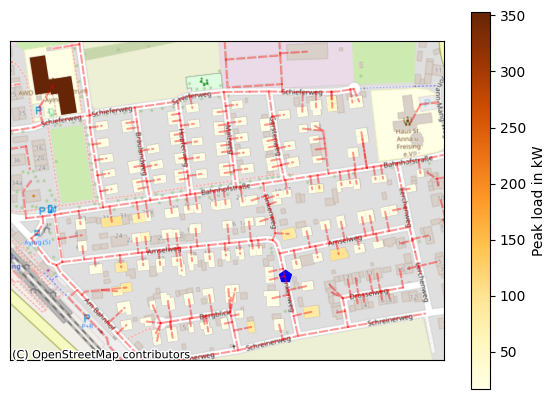

In [14]:
# The area around the grid
cluster_region = grid_buildings_gdf.dissolve().convex_hull.buffer(50)
cluster_region_gdf = gpd.GeoDataFrame(geometry=cluster_region)
grid_ways_gdf = gpd.sjoin(ways_gdf, cluster_region_gdf, how="inner")
grid_ways_gdf.plot(ax=ax, edgecolor="red", linestyle="--", alpha=0.4, label="Streets")
fig

## Generated grid
pylovo joins all the elements shown above into a pandapower network.

In [15]:
net = dbc.read_net_db(plz=plz, kcid=kcid, bcid=bcid)
net

This pandapower network includes the following parameter tables:
   - bus (283 elements)
   - load (144 elements)
   - ext_grid (1 element)
   - line (281 elements)
   - trafo (1 element)
 and the following results tables:
   - res_bus (283 elements)
   - res_line (281 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (144 elements)

The network only contains the cable routes along the streets that are needed to supply all consumers (buildings). The line coordinates (GeoJSON in WGS84) are converted to the coordinate system of the buildings:

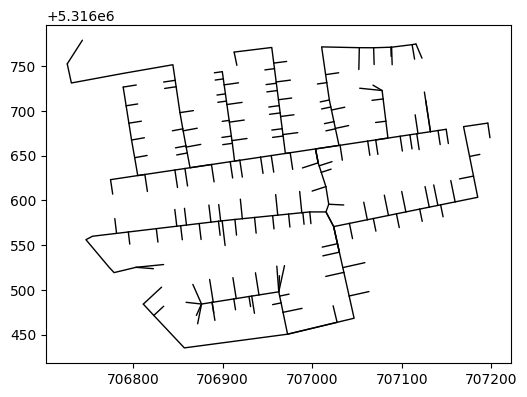

In [16]:
line_gdf, bus_gdf = get_bus_line_geo_for_network(net, plz)
line_gdf = line_gdf.set_crs("EPSG:4326").to_crs(grid_buildings_gdf.crs)
line_gdf.plot(edgecolor="black", linewidth=1, figsize=(6, 6));

Now all the elements are put together: transformer, cables and consumers.

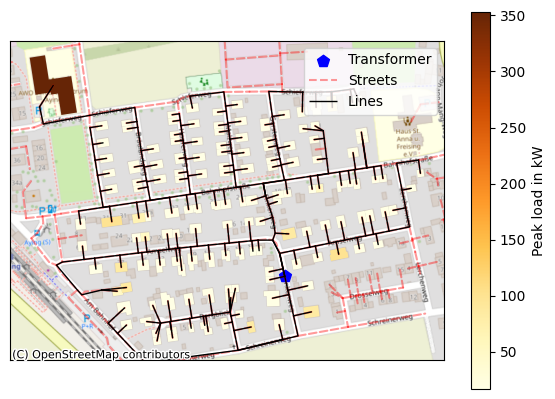

In [17]:
line_gdf.plot(ax=ax, edgecolor="black", linewidth=1, label="Lines")
ax.legend()
fig

Some buildings on the basemap belong to a different grid or are not supplied: outbuildings without consumers, and commercial or public buildings with a peak load above `MV_DIRECT_CONNECTION_LOAD_THRESHOLD_KW` (`config/config_generation.yaml`), which are assumed to be connected directly to the MV grid.

The next notebook, `2_0_LV_pandapower_network.ipynb`, shows the data behind the network.